# LUAD Telomere Maintenance Panel: Survival Analysis
**Author:** SadaSiva | **Date:** September 2026

**Objective:** Investigate the prognostic impact of telomerase (TERT/TERC) and ALT-associated (ATRX/DAXX/PML/RAD52) gene expression in lung adenocarcinoma (LUAD) using TCGA data, adjusting for clinical covariates and time-varying hazards.

In [3]:
# Block 1: Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from pathlib import Path
import warnings

# Suppress minor pandas fragmentation warnings for clean output
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

# Set global plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Define DATA directory
DATA_DIR = Path("DATA")

In [4]:
# Block 2: Data Ingestion and Mapping

# 1. Load the raw expression data
expr_file = DATA_DIR / "luad_telomere_panel.tsv"
expr_df = pd.read_csv(expr_file, sep='\t')

# 2. Rename Ensembl IDs to HGNC Symbols using our verified mapping
gene_mapping = {
    'ENSG00000164362.21': 'TERT',
    'ENSG00000085224.23': 'ATRX',
    'ENSG00000204209.13': 'DAXX',
    'ENSG00000270141.3':  'TERC',
    'ENSG00000140464.20': 'PML',
    'ENSG00000002016.18': 'RAD52'
}
expr_df = expr_df.rename(columns=gene_mapping)

# 3. Create the event indicator (Alive = 0, Dead = 1)
# Using 'Int64' preserves missing (NaN) values instead of converting them to 0 (censored)
event_map = {'Alive': 0, 'Dead': 1}
expr_df['event'] = expr_df['vital_status.demographic'].map(event_map).astype('Int64')

# 4. Subset to our core analysis columns
cols_to_keep = [
    'sample', 'OS.time', 'event', 
    'TERT', 'ATRX', 'DAXX', 'TERC', 'PML', 'RAD52'
]
analysis_df = expr_df[cols_to_keep]

print(f"Expression data loaded: {analysis_df.shape[0]} rows, {analysis_df.shape[1]} columns.")
print(f"Survival events summary:\n{analysis_df['event'].value_counts(dropna=False)}")

Expression data loaded: 721 rows, 9 columns.
Survival events summary:
event
0       411
1       247
<NA>     63
Name: count, dtype: Int64


In [9]:
# Block 3: Clinical Integration and Cleaning
from sklearn.preprocessing import StandardScaler

# 1. Load the clinical data
clinical_file = DATA_DIR / "luad_telomere_clinical_panel.tsv"
clinical_df = pd.read_csv(clinical_file, sep='\t')

# 2. Merge ONLY the new clinical columns to avoid _x/_y suffix conflicts
clinical_cols_to_merge = [
    'sample', 
    'age_at_diagnosis.diagnoses', 
    'ajcc_pathologic_stage.diagnoses', 
    'gender.demographic'
]
merged_df = pd.merge(analysis_df, clinical_df[clinical_cols_to_merge], on='sample', how='inner')

# 3. Clean Age (Convert days to years)
merged_df['age_years'] = merged_df['age_at_diagnosis.diagnoses'] / 365.25

# 4. Clean Stage (Group sub-stages into major Stage I, II, III, IV groups)
def map_stage(stage_str):
    if pd.isna(stage_str): return np.nan
    # Order matters: check IV and III before I
    if 'Stage IV' in stage_str: return 'Stage IV'
    elif 'Stage III' in stage_str: return 'Stage III'
    elif 'Stage II' in stage_str: return 'Stage II'
    elif 'Stage I' in stage_str: return 'Stage I'
    return np.nan
merged_df['stage_group'] = merged_df['ajcc_pathologic_stage.diagnoses'].apply(map_stage)

# 5. Clean Gender (Female as reference = 0, Male = 1)
merged_df['is_male'] = (merged_df['gender.demographic'] == 'male').astype(int)

# 6. Filter down to the complete-case survival cohort
# Drop rows missing survival, event, age, stage, or genes, and exclude time <= 0
core_cols = ['OS.time', 'event', 'age_years', 'stage_group'] + ['TERT', 'ATRX', 'DAXX', 'TERC', 'PML', 'RAD52']
complete_df = merged_df.dropna(subset=core_cols).copy()
survival_df = complete_df[complete_df['OS.time'] > 0].copy()

# 7. Z-standardize age and the 6 genes for interpretable Hazard Ratios
scaler = StandardScaler()
cols_to_scale = ['age_years', 'TERT', 'ATRX', 'DAXX', 'TERC', 'PML', 'RAD52']
survival_df[cols_to_scale] = scaler.fit_transform(survival_df[cols_to_scale])

print(f"Final Survival Cohort: {survival_df.shape[0]} patients, {survival_df['event'].sum()} events.")
print("\nStage Breakdown:")
print(survival_df['stage_group'].value_counts())

Final Survival Cohort: 539 patients, 196 events.

Stage Breakdown:
stage_group
Stage I      298
Stage II     122
Stage III     92
Stage IV      27
Name: count, dtype: int64


In [11]:
# Block 4: Primary Survival Model
from lifelines import CoxPHFitter
import numpy as np

# 1. Create the time-varying interaction term for TERT
# Centering log-time at 365 days makes the main TERT HR interpretable as the effect at exactly 1 year
survival_df['log_time_centered'] = np.log1p(survival_df['OS.time']) - np.log1p(365)
survival_df['TERT_time_interaction'] = survival_df['TERT'] * survival_df['log_time_centered']

# 2. Subset the dataframe for the model
model_cols = [
    'OS.time', 'event', 'stage_group', 'is_male', 'age_years', 
    'TERT', 'TERT_time_interaction', 'ATRX', 'DAXX', 'TERC', 'PML', 'RAD52'
]
model_df = survival_df[model_cols].copy()

# 3. Fit the stage-stratified Cox Proportional Hazards model
cph_stratified = CoxPHFitter()
cph_stratified.fit(
    model_df, 
    duration_col='OS.time', 
    event_col='event', 
    strata=['stage_group']
)

# 4. Display the core results
cph_stratified.print_summary(
    columns=['coef', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p'], 
    decimals=3
)

<lifelines.CoxPHFitter: fitted with 539 total observations, 343 right-censored observations>
             duration col = 'OS.time'
                event col = 'event'
                   strata = stage_group
      baseline estimation = breslow
   number of observations = 539
number of events observed = 196
   partial log-likelihood = -771.545
         time fit was run = 2026-09-11 10:21:02 UTC

---
                        coef exp(coef) exp(coef) lower 95% exp(coef) upper 95%       p
covariate                                                                             
is_male                0.090     1.094               0.814               1.471   0.552
age_years              0.074     1.077               0.922               1.257   0.349
TERT                   0.348     1.416               1.218               1.645 <0.0005
TERT_time_interaction -0.331     0.718               0.620               0.833 <0.0005
ATRX                  -0.017     0.983               0.838               1.153   0.833
DAXX                   0.044     1.044               0.885               1.233   0.607
TERC                   0.151     1.162               1.021               1.323   0.023
PML                    0.076     1.079               0.918               1.269   0.355
RAD52                 -0.054     0.948               0.814               1.103   0.489
---
Concordance = 0.546
Partial AIC = 1561.090
log-likelihood ratio test = 29.449 on 9 df
-log2(p) of ll-ratio test = 10.843

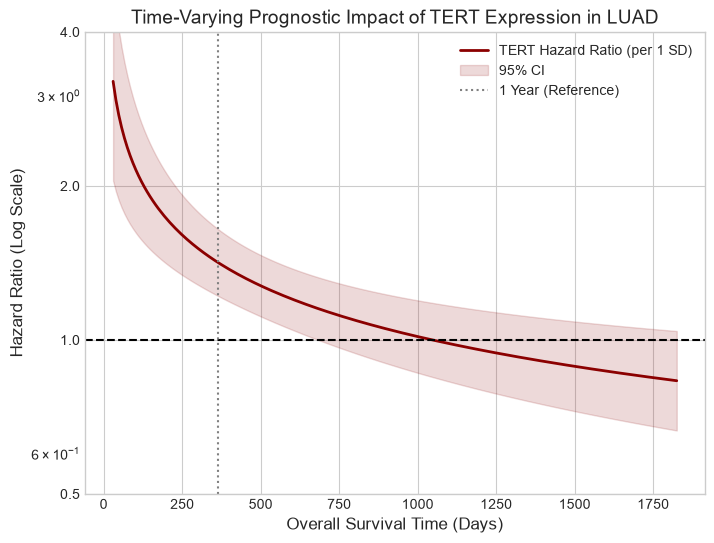

Pipeline complete. Plot saved successfully to: DATA\luad_TERT_time_varying_hazard_ratio_stage_stratified.png


In [12]:
# Block 5: The TERT Hazard Ratio Curve (Visualization and Export)
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract coefficients and variances for TERT and its interaction
tert_coef = cph_stratified.params_['TERT']
int_coef = cph_stratified.params_['TERT_time_interaction']

cov_matrix = cph_stratified.variance_matrix_.loc[
    ['TERT', 'TERT_time_interaction'], 
    ['TERT', 'TERT_time_interaction']
]
var_tert = cov_matrix.loc['TERT', 'TERT']
var_int = cov_matrix.loc['TERT_time_interaction', 'TERT_time_interaction']
cov_tert_int = cov_matrix.loc['TERT', 'TERT_time_interaction']

# 2. Generate time sequence (30 days to 5 years) and apply centering
t = np.linspace(30, 1825, 200)
log_t_centered = np.log1p(t) - np.log1p(365)

# 3. Calculate time-dependent log(HR) and standard error
log_hr = tert_coef + int_coef * log_t_centered
se_log_hr = np.sqrt(var_tert + (log_t_centered**2) * var_int + 2 * log_t_centered * cov_tert_int)

# 4. Convert to HR and 95% Confidence Intervals
hr = np.exp(log_hr)
upper_ci = np.exp(log_hr + 1.96 * se_log_hr)
lower_ci = np.exp(log_hr - 1.96 * se_log_hr)

# 5. Build the figure
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(t, hr, color='darkred', linewidth=2, label='TERT Hazard Ratio (per 1 SD)')
ax.fill_between(t, lower_ci, upper_ci, color='darkred', alpha=0.15, label='95% CI')
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5)
ax.axvline(x=365, color='gray', linestyle=':', linewidth=1.5, label='1 Year (Reference)')

# Formatting
ax.set_title('Time-Varying Prognostic Impact of TERT Expression in LUAD')
ax.set_xlabel('Overall Survival Time (Days)')
ax.set_ylabel('Hazard Ratio (Log Scale)')
ax.set_yscale('log')
ax.set_ylim(0.5, 4.0)
ax.set_yticks([0.5, 1.0, 2.0, 4.0])
ax.set_yticklabels(['0.5', '1.0', '2.0', '4.0'])
ax.legend(loc='upper right')

# 6. Save first, then show (fixes the blank PNG issue)
output_path = DATA_DIR / 'luad_TERT_time_varying_hazard_ratio_stage_stratified.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Pipeline complete. Plot saved successfully to: {output_path}")

In [13]:
# Block 6: Mutation Data Inspection
mut_file = DATA_DIR / "luad_mutations.tsv"
mut_df = pd.read_csv(mut_file, sep='\t')

print(f"Mutation data loaded: {mut_df.shape[0]} rows, {mut_df.shape[1]} columns")
print("\nColumns:", mut_df.columns.tolist())
display(mut_df.head())

Mutation data loaded: 16 rows, 509 columns

Columns: ['track_name', 'track_type', 'TCGA-05-4402', 'TCGA-44-2662', 'TCGA-55-8506', 'TCGA-44-8117', 'TCGA-50-5944', 'TCGA-50-6594', 'TCGA-38-4631', 'TCGA-L9-A8F4', 'TCGA-99-7458', 'TCGA-78-7149', 'TCGA-05-4396', 'TCGA-05-4424', 'TCGA-44-3919', 'TCGA-44-5644', 'TCGA-44-7659', 'TCGA-44-7662', 'TCGA-49-AAR2', 'TCGA-49-4505', 'TCGA-50-5045', 'TCGA-50-5066', 'TCGA-50-5931', 'TCGA-50-6593', 'TCGA-55-A4DG', 'TCGA-55-A491', 'TCGA-55-6969', 'TCGA-55-6972', 'TCGA-55-6982', 'TCGA-55-7726', 'TCGA-55-7910', 'TCGA-55-8510', 'TCGA-55-8514', 'TCGA-62-A471', 'TCGA-62-8395', 'TCGA-62-8402', 'TCGA-64-1679', 'TCGA-64-1681', 'TCGA-64-5778', 'TCGA-67-3770', 'TCGA-69-7765', 'TCGA-69-7979', 'TCGA-73-4668', 'TCGA-J2-A4AD', 'TCGA-75-5122', 'TCGA-75-5125', 'TCGA-75-5147', 'TCGA-75-6205', 'TCGA-75-6207', 'TCGA-L9-A743', 'TCGA-MP-A4T4', 'TCGA-MP-A4TC', 'TCGA-MP-A4TH', 'TCGA-MP-A4TK', 'TCGA-NJ-A55O', 'TCGA-86-7711', 'TCGA-86-7953', 'TCGA-86-8073', 'TCGA-86-8074', 'TCGA-

,track_name,track_type,TCGA-05-4402,TCGA-44-2662,TCGA-55-8506,TCGA-44-8117,TCGA-50-5944,TCGA-50-6594,TCGA-38-4631,TCGA-L9-A8F4,...,TCGA-97-8171,TCGA-97-8172,TCGA-97-8175,TCGA-97-8176,TCGA-97-8177,TCGA-97-8179,TCGA-97-8547,TCGA-99-AA5R,TCGA-99-8025,TCGA-99-8033
0,Profiled in SV Data,CLINICAL,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
1,TERT,CNA,amp_rec,NaN,amp_rec,amp_rec,amp_rec,amp_rec,amp_rec,amp_rec,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ATRX,CNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,DAXX,CNA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TERT,MUTATIONS,NaN,NaN,Missense Mutation (putative passenger),Missense Mutation (putative passenger),NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Block 7: Reshape and Inspect Genomic Alterations

# 1. Print all track types present
print("Track inventory:")
display(mut_df[['track_name', 'track_type']])

# 2. Reshape: Melt patient columns into rows
patient_cols = [c for c in mut_df.columns if c.startswith('TCGA')]

# Combine track_name and track_type into a clean feature label
mut_df['feature'] = mut_df['track_name'] + "_" + mut_df['track_type']

# Pivot so patients are rows and features are columns
tidy_mut = mut_df.set_index('feature')[patient_cols].T
tidy_mut.index.name = 'patient_id'
tidy_mut = tidy_mut.reset_index()

# 3. Create a matching patient_id in survival_df (first 12 characters of sample barcode)
survival_df['patient_id'] = survival_df['sample'].str.slice(0, 12)

# 4. Check patient barcode overlap
cohort_patients = set(survival_df['patient_id'])
mut_patients = set(tidy_mut['patient_id'])
overlap = cohort_patients.intersection(mut_patients)

print(f"\nCohort patients: {len(cohort_patients)}")
print(f"cBioPortal patients: {len(mut_patients)}")
print(f"Overlap: {len(overlap)} matching patients")

display(tidy_mut.head())

Track inventory:


,track_name,track_type
0,Profiled in SV Data,CLINICAL
1,TERT,CNA
2,ATRX,CNA
3,DAXX,CNA
4,TERT,MUTATIONS
5,ATRX,MUTATIONS
6,DAXX,MUTATIONS
7,TERT,MRNA
8,ATRX,MRNA
9,DAXX,MRNA



Cohort patients: 475
cBioPortal patients: 507
Overlap: 464 matching patients


feature,patient_id,Profiled in SV Data_CLINICAL,TERT_CNA,ATRX_CNA,DAXX_CNA,TERT_MUTATIONS,ATRX_MUTATIONS,DAXX_MUTATIONS,TERT_MRNA,ATRX_MRNA,DAXX_MRNA,TERT_PROTEIN,ATRX_PROTEIN,DAXX_PROTEIN,TERT_STRUCTURAL_VARIANT,ATRX_STRUCTURAL_VARIANT,DAXX_STRUCTURAL_VARIANT
0,TCGA-05-4402,Yes,amp_rec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sv,NaN,NaN
1,TCGA-44-2662,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sv,NaN,NaN
2,TCGA-55-8506,Yes,amp_rec,NaN,NaN,Missense Mutation (putative passenger),Missense Mutation (putative passenger),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TCGA-44-8117,Yes,amp_rec,NaN,NaN,Missense Mutation (putative passenger),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TCGA-50-5944,Yes,amp_rec,NaN,NaN,NaN,Truncating mutation (putative driver),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# Block 8: Process Genomic Alterations and Create Feature Flags

# 1. Inspect unique values across the alteration columns
alteration_tracks = [
    'TERT_CNA', 'TERT_MUTATIONS', 'TERT_STRUCTURAL_VARIANT',
    'ATRX_CNA', 'ATRX_MUTATIONS', 'ATRX_STRUCTURAL_VARIANT',
    'DAXX_CNA', 'DAXX_MUTATIONS', 'DAXX_STRUCTURAL_VARIANT'
]

print("Distinct alteration categories observed:")
for col in alteration_tracks:
    vals = tidy_mut[col].dropna().unique().tolist()
    print(f"  {col}: {vals[:5]}")

# 2. Define binary alteration flags (1 if any non-null alteration exists, else 0)
# TERT alteration: amplification, mutation, or structural variant
tidy_mut['TERT_genomic_alt'] = tidy_mut[['TERT_CNA', 'TERT_MUTATIONS', 'TERT_STRUCTURAL_VARIANT']].notna().any(axis=1).astype(int)

# ATRX / DAXX alterations (classic ALT-associated genes)
tidy_mut['ATRX_genomic_alt'] = tidy_mut[['ATRX_CNA', 'ATRX_MUTATIONS', 'ATRX_STRUCTURAL_VARIANT']].notna().any(axis=1).astype(int)
tidy_mut['DAXX_genomic_alt'] = tidy_mut[['DAXX_CNA', 'DAXX_MUTATIONS', 'DAXX_STRUCTURAL_VARIANT']].notna().any(axis=1).astype(int)

# Combined ALT proxy: alteration in either ATRX or DAXX
tidy_mut['ALT_pathway_alt'] = ((tidy_mut['ATRX_genomic_alt'] == 1) | (tidy_mut['DAXX_genomic_alt'] == 1)).astype(int)

# 3. Subset to patient ID and the binary genomic features
genomic_features = tidy_mut[['patient_id', 'TERT_genomic_alt', 'ATRX_genomic_alt', 'DAXX_genomic_alt', 'ALT_pathway_alt']].drop_duplicates()

# 4. Merge with survival cohort (keeping matched samples)
multiomics_df = pd.merge(survival_df, genomic_features, on='patient_id', how='inner')

print(f"\nMulti-omics cohort: {multiomics_df.shape[0]} samples, {multiomics_df['event'].sum()} events.")
print("\nGenomic Alteration Counts:")
print(f"  TERT altered: {multiomics_df['TERT_genomic_alt'].sum()} ({multiomics_df['TERT_genomic_alt'].mean():.1%})")
print(f"  ATRX altered: {multiomics_df['ATRX_genomic_alt'].sum()} ({multiomics_df['ATRX_genomic_alt'].mean():.1%})")
print(f"  DAXX altered: {multiomics_df['DAXX_genomic_alt'].sum()} ({multiomics_df['DAXX_genomic_alt'].mean():.1%})")
print(f"  ALT pathway (ATRX or DAXX) altered: {multiomics_df['ALT_pathway_alt'].sum()} ({multiomics_df['ALT_pathway_alt'].mean():.1%})")

Distinct alteration categories observed:
  TERT_CNA: ['amp_rec']
  TERT_MUTATIONS: ['Missense Mutation (putative passenger)']
  TERT_STRUCTURAL_VARIANT: ['sv']
  ATRX_CNA: ['Amplification']
  ATRX_MUTATIONS: ['Missense Mutation (putative passenger)', 'Truncating mutation (putative driver)', 'splice_rec']
  ATRX_STRUCTURAL_VARIANT: []
  DAXX_CNA: ['Amplification']
  DAXX_MUTATIONS: ['Missense Mutation (putative passenger)']
  DAXX_STRUCTURAL_VARIANT: []

Multi-omics cohort: 525 samples, 189 events.

Genomic Alteration Counts:
  TERT altered: 69 (13.1%)
  ATRX altered: 30 (5.7%)
  DAXX altered: 12 (2.3%)
  ALT pathway (ATRX or DAXX) altered: 42 (8.0%)


In [16]:
# Block 9: Multi-Omics Survival Model
from lifelines import CoxPHFitter
import numpy as np

# 1. Re-apply the 365-day centering for TERT expression for the matched cohort
multiomics_df['log_time_centered'] = np.log1p(multiomics_df['OS.time']) - np.log1p(365)
multiomics_df['TERT_time_interaction'] = multiomics_df['TERT'] * multiomics_df['log_time_centered']

# 2. Select variables for the integrated multi-omics model
# We include both the RNA expression variables and our new DNA alteration flags
multi_model_cols = [
    'OS.time', 'event', 'stage_group', 'is_male', 'age_years', 
    'TERT', 'TERT_time_interaction', 'TERT_genomic_alt',
    'ATRX', 'DAXX', 'TERC', 'PML', 'RAD52', 'ALT_pathway_alt'
]
multi_model_df = multiomics_df[multi_model_cols].copy()

# 3. Fit the multi-omics stage-stratified Cox model
cph_multi = CoxPHFitter()
cph_multi.fit(
    multi_model_df, 
    duration_col='OS.time', 
    event_col='event', 
    strata=['stage_group']
)

# 4. Display the core results
cph_multi.print_summary(
    columns=['coef', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p'], 
    decimals=3
)

<lifelines.CoxPHFitter: fitted with 525 total observations, 336 right-censored observations>
             duration col = 'OS.time'
                event col = 'event'
                   strata = stage_group
      baseline estimation = breslow
   number of observations = 525
number of events observed = 189
   partial log-likelihood = -742.059
         time fit was run = 2026-09-11 11:15:58 UTC

---
                        coef exp(coef) exp(coef) lower 95% exp(coef) upper 95%       p
covariate                                                                             
is_male                0.088     1.092               0.804               1.482   0.573
age_years              0.094     1.099               0.938               1.287   0.242
TERT                   0.345     1.412               1.206               1.652 <0.0005
TERT_time_interaction -0.318     0.727               0.625               0.847 <0.0005
TERT_genomic_alt      -0.271     0.762               0.476               1.220   0.258
ATRX                  -0.029     0.971               0.824               1.145   0.730
DAXX                   0.046     1.047               0.879               1.248   0.607
TERC                   0.133     1.142               0.993               1.314   0.063
PML                    0.081     1.084               0.919               1.280   0.340
RAD52                 -0.056     0.946               0.811               1.103   0.479
ALT_pathway_alt       -0.160     0.852               0.459               1.580   0.611
---
Concordance = 0.558
Partial AIC = 1506.119
log-likelihood ratio test = 26.567 on 11 df
-log2(p) of ll-ratio test = 7.549

In [17]:
# Block 10: Export Final Multi-Omics Dataset
output_csv = DATA_DIR / "luad_multiomics_survival_cohort.csv"
multiomics_df.to_csv(output_csv, index=False)
print(f"Multi-omics cohort saved to: {output_csv}")

Multi-omics cohort saved to: DATA\luad_multiomics_survival_cohort.csv
